In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=10000,test_split=0.2)
word_index = reuters.get_word_index()

In [3]:
category = np.max(y_train)
print(category)
print('test :',len(X_test))
print('train :',len(X_train))
print(X_train[0])

45
test : 2246
train : 8982
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [4]:
# 입력된 기사의 단어수를 동일하게 맞춤
# => 모자라는 부분은 0으로 채우고, 남으면 100개째의 다너만 선택하고 나머지를 버림

X_train = sequence.pad_sequences(X_train,maxlen=100)
X_test = sequence.pad_sequences(X_test,maxlen=100)

In [6]:
# one hot encodding

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [7]:
# modeling

model = Sequential()
model.add(Embedding(10000,1000))
model.add(LSTM(100,activation='tanh'))
model.add(Dense(46,activation='softmax'))

In [8]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    batch_size=20,
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/200
450/450 [==============================] - 9s 14ms/step - loss: 1.8950 - accuracy: 0.5208 - val_loss: 1.5939 - val_accuracy: 0.6091
Epoch 2/200
450/450 [==============================] - 6s 12ms/step - loss: 1.2295 - accuracy: 0.6980 - val_loss: 1.2959 - val_accuracy: 0.6928
Epoch 3/200
450/450 [==============================] - 6s 12ms/step - loss: 0.7897 - accuracy: 0.8059 - val_loss: 1.2165 - val_accuracy: 0.7119
Epoch 4/200
450/450 [==============================] - 6s 12ms/step - loss: 0.4679 - accuracy: 0.8888 - val_loss: 1.2444 - val_accuracy: 0.7150
Epoch 5/200
450/450 [==============================] - 5s 12ms/step - loss: 0.2790 - accuracy: 0.9342 - val_loss: 1.2838 - val_accuracy: 0.7253
Epoch 6/200
450/450 [==============================] - 6s 12ms/step - loss: 0.1962 - accuracy: 0.9472 - val_loss: 1.3971 - val_accuracy: 0.7213
Epoch 7/200
450/450 [==============================] - 6s 12ms/step - loss: 0.1487 - accuracy: 0.9502 - val_loss: 1.3989 - val_accuracy:

In [11]:
acc = model.evaluate(X_test, y_test)[1]
print(acc)

71/71 [==============================] - 1s 10ms/step - loss: 1.2165 - accuracy: 0.7119
0.7119323015213013


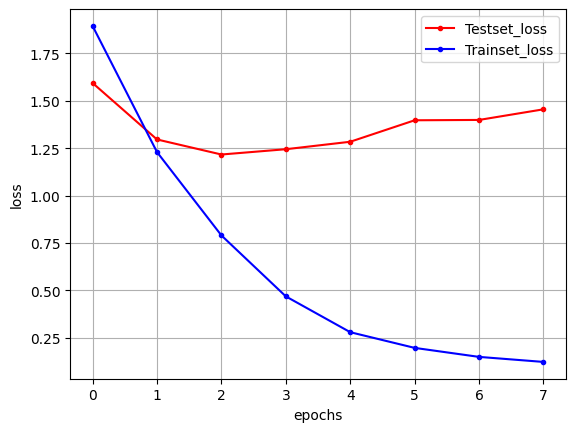

In [12]:
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')
plt.plot(x_len,y_loss,marker='.',c='blue',label='Trainset_loss')

plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [21]:
word_index = reuters.get_word_index()

def encode_text(text,word_index,num_words=1000):
    words = re.findall(r"[a-zA-Z]+",text.lower())
    encoded = [1]

    for word in words:
        idx = word_index.get(word)
        if idx is not None:
            idx = idx+3
            if idx < num_words:
                encoded.append(idx)
            else:
                encoded.append(2)
        else:
            encoded.append(2)
    return encoded

In [28]:
import re

def predict_article_category(text):
    encoded = encode_text(text,word_index,num_words=1000)
    padded = sequence.pad_sequences([encoded],maxlen=100)
    prediction = model.predict(padded)
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction)
    return predicted_label,confidence

In [29]:
reuters_labels = {
    0: "cocoa", 1: "grain", 2: "crude oil", 3: "money markets", 4: "interest rates",
    5: "trade", 6: "reserves", 7: "ship", 8: "cotton", 9: "coffee",
    10: "gold", 11: "veg-oil", 12: "wheat", 13: "earnings", 14: "acquisitions",
    15: "money supply", 16: "meat", 17: "retail", 18: "alum", 19: "strategic metals",
    20: "grain/livestock", 21: "energy", 22: "housing", 23: "rubber", 24: "cpi",
    25: "money-fx", 26: "interest", 27: "copper", 28: "tin", 29: "strategic planning",
    30: "carcass", 31: "oilseed", 32: "jobs", 33: "lead", 34: "livestock",
    35: "zinc", 36: "meal-feed", 37: "sugar", 38: "shipping", 39: "iron-steel",
    40: "money market operations", 41: "gnp", 42: "bop", 43: "money-supply",
    44: "rubber-market", 45: "oilseed-market"
}


reuters_labels_ko = {
    0: "코코아",
    1: "곡물",
    2: "원유",
    3: "단기 금융시장",
    4: "이자율",
    5: "무역",
    6: "외환보유고",
    7: "선박",
    8: "면화",
    9: "커피",
    10: "금",
    11: "식물성 오일",
    12: "밀",
    13: "수익",
    14: "인수합병",
    15: "통화공급",
    16: "육류",
    17: "소매",
    18: "알루미늄",
    19: "전략금속",
    20: "곡물/가축",
    21: "에너지",
    22: "주택",
    23: "고무",
    24: "소비자물가지수(CPI)",
    25: "외환시장",
    26: "이자",
    27: "구리",
    28: "주석",
    29: "전략기획",
    30: "도체",
    31: "유종(기름 씨앗)",
    32: "고용",
    33: "납",
    34: "가축",
    35: "아연",
    36: "사료",
    37: "설탕",
    38: "해운",
    39: "철강",
    40: "단기금융조작",
    41: "국민총생산(GNP)",
    42: "국제수지(BOP)",
    43: "통화 공급량",
    44: "고무시장",
    45: "기름 씨앗 시장"
}

In [33]:
sample_text = "South Korea's exports surged 53 percent from a year earlier to a new monthly high of $87.8 billion in May, driven by the semiconductor supercycle, government data showed Monday. It marked the third consecutive month the countrys outbound shipments surpassed the $80 billion mark, according to the Ministry of Trade, Industry and Resources."
label,confidence = predict_article_category(sample_text)
category_en = reuters_labels.get(label,'Unknown')
category_ko = reuters_labels_ko.get(label,'알 수 없음')
print(label,category_en , ':' , label,category_ko)

1/1 [==============================] - 0s 35ms/step
11 veg-oil : 11 식물성 오일


In [35]:
sample_text = "The Mean of Platts Singapore, a benchmark for refined petroleum products in the Asia-Pacific region, averaged $214.71 per barrel between March 16 and April 15, placing fuel surcharges for the month in the highest Level 33 bracket.\
Amid rising fuel costs and falling passenger demand, local low-cost carriers have reduced round-trip services and introduced unpaid leave and other emergency measures.\
Jeju Air Co., South Korea's largest budget airline, has cut nearly 200 round-trip international flights, equivalent to 4 percent of its total operations, \
on routes from Incheon, west of Seoul, to Bangkok, Singapore, and the Vietnamese cities of Da Nang and Phu Quoc during May and June. Since late April, it has also suspended its Vientiane route for two months. (Yonhap)"
label, confidence = predict_article_category(sample_text)
label,confidence = predict_article_category(sample_text)
category_en = reuters_labels.get(label,'Unknown')
category_ko = reuters_labels_ko.get(label,'알 수 없음')
print(label,category_en , ':' , label,category_ko)

1/1 [==============================] - 0s 31ms/step
4 interest rates : 4 이자율


In [36]:
sample_text = "The Korean won briefly breached the 1,560-per-dollar level in overnight trading Friday, \
falling to its weakest point since the global financial crisis and prompting authorities to launch a probe into suspected speculative trading and \
market-disruptive activity. The won closed at 1,559 per dollar in Seoul's overnight market at 2 a.m. Saturday after touching \
1,561.5 during the session, its weakest level since March 2009. The slide accelerated after the dollar-won rate ended Friday's regular session at \
1,539.1, up 9.4 won from a day earlier. Stronger-than-expected US jobs data boosted expectations that the Federal Reserve could resume \
interest-rate hikes later this year, sending the dollar higher against major currencies. In response, Finance Minister and \
Deputy Prime Minister Koo Yun-cheol held an emergency market review meeting on Sunday with the heads of the Bank of Korea, \
Financial Services Commission and Financial Supervisory Service, issuing a stronger warning after two verbal interventions earlier in \
the week failed to slow the won's slide. <While the recent increase in foreign exchange volatility reflects supply-demand factors,\
such as foreign investors portfolio rebalancing and profit-taking amid strength in the domestic stock market, some speculative trading has \
accelerated one-sided moves,> Koo said. He said authorities would inspect suspected speculative or market-disruptive activity and illegal \
foreign exchange transactions, and that they would take strict action depending on the findings."
label, confidence = predict_article_category(sample_text)
label,confidence = predict_article_category(sample_text)
category_en = reuters_labels.get(label,'Unknown')
category_ko = reuters_labels_ko.get(label,'알 수 없음')
print(label,category_en , ':' , label,category_ko)

1/1 [==============================] - 0s 31ms/step
4 interest rates : 4 이자율
